<a href="https://colab.research.google.com/github/EonSoulCout/Integrador-EthnicEcuadorian-Clasificador/blob/main/Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador - Visión por Computador
## Meta 1: Selección y Análisis del Dataset

**Dataset:** [Dataset of Ethnic facial images of Ecuadorian people](https://figshare.com/articles/dataset/Dataset_of_Ethnic_facial_images_of_Ecuadorian_people/8266730)

**Clases:** European descendants, Afro-ecuadorians, Indigenous, Mestizos

Este notebook cubre:
1. Importación de librerías
2. Carga del dataset (Google Drive / local)
3. Análisis básico: número de instancias total y por clase, número de clases, resolución promedio, formatos
4. Visualización de la distribución de clases y muestras de imágenes

## 1. Librerías

| Librería | Uso en este proyecto |
|---|---|
| `os` | Recorrer carpetas del dataset (listar clases y archivos) |
| `glob` | Buscar rutas de imágenes con patrones (`*.jpg`, `*.png`, etc.) |
| `cv2` (OpenCV) | Leer imágenes, obtener resolución, y más adelante preprocesamiento y extracción de características |
| `numpy` | Cálculos numéricos (promedios de resolución, arreglos de características) |
| `pandas` | Organizar resultados en tablas (DataFrames) y exportar a CSV |
| `matplotlib` | Graficar la distribución de clases y mostrar imágenes de ejemplo |
| `seaborn` | Gráficas estadísticas con mejor estilo (barras, histogramas) |
| `PIL` (Pillow) | Verificación adicional de formato/metadatos de imagen (respaldo de OpenCV) |
| `pathlib` | Manejo más legible de rutas de archivos |

Si más adelante usamos librerías adicionales (p. ej. `scikit-image` para LBP, `scikit-learn` para clustering/clasificación), las iremos agregando aquí.

In [12]:
# Librerías estándar
import os
import glob
from pathlib import Path

# Manejo de imágenes
import cv2
from PIL import Image

# Cálculo numérico y tablas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

import os
import cv2
import glob
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import time

import os
import glob
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import os
import cv2
import glob
import time
import numpy as np
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import os
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import os
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Configuración de estilo para las gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías cargadas correctamente.')
print('OpenCV version:', cv2.__version__)

Librerías cargadas correctamente.
OpenCV version: 4.13.0


## 2. Configuración del Entorno y Carga de Datos

Para garantizar la reproducibilidad del experimento, se establece la conexión con el sistema de almacenamiento en la nube (Google Drive) y se definen las rutas absolutas del directorio de trabajo. Se verifica la integridad de la ruta para asegurar que los procesos posteriores interactúen exclusivamente con el conjunto de datos definido para este proyecto.

In [2]:

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta específica del proyecto (basado en la estructura de la imagen)
DATASET_PATH = '/content/drive/MyDrive/Intregrador/8266730'
OUTPUT_PATH = '/content/drive/MyDrive/Intregrador/outputs'

# Verificar que la ruta del dataset exista antes de continuar
if os.path.exists(DATASET_PATH):
    print(f"✓ Ruta del dataset verificada correctamente: {DATASET_PATH}")
    # Crear carpeta de salidas si no existe
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    print(f"✓ Directorio de salida configurado en: {OUTPUT_PATH}")
else:
    print(f"⚠ ERROR: No se encontró la ruta {DATASET_PATH}. Verifica el nombre de las carpetas.")

Mounted at /content/drive
✓ Ruta del dataset verificada correctamente: /content/drive/MyDrive/Intregrador/8266730
✓ Directorio de salida configurado en: /content/drive/MyDrive/Intregrador/outputs


## 3. Análisis Exploratorio del Dataset (EDA)

Antes de proceder con el preprocesamiento y la extracción de características, se realiza un análisis descriptivo del conjunto de imágenes. Este proceso identifica métricas fundamentales como el volumen total de instancias, la distribución de clases, la resolución espacial promedio y los formatos de archivo presentes.

Esta etapa es crítica para detectar anomalías, como el desbalanceo de clases, que puedan comprometer el entrenamiento de los modelos de Machine Learning.

--- REPORTE DE ANÁLISIS BÁSICO ---
Total de instancias procesadas: 430
Número total de clases: 4

Distribución de instancias por clase:
               clase  num_instancias
            Mestizos             280
    Afro-ecuadorians              50
European descendants              50
          Indigenous              50

Resolución promedio: 1280 x 1920 px
Resolución mínima detectada: 1280 x 1862 px
Resolución máxima detectada: 1280 x 1920 px

Formatos de archivo encontrados: ['jpg']

[!] ADVERTENCIA CRÍTICA: Dataset altamente desbalanceado (Ratio clase mayor/menor = 5.6x).
    -> Se recomienda aplicar técnicas de balanceo (SMOTE, class_weight) en la fase de modelado.


/tmp/ipykernel_886/2481649450.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_clases, x='clase', y='num_instancias', palette='viridis')


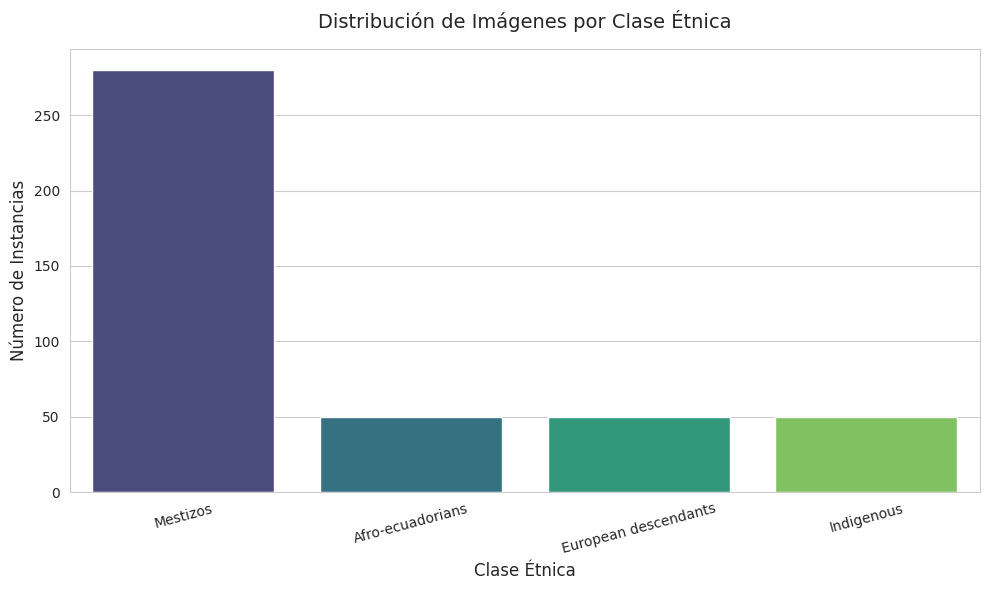

In [3]:

def analisis_basico(dataset_path):
    """
    Recorre las subcarpetas (clases) de dataset_path y calcula métricas descriptivas.
    Excluye directorios no correspondientes a clases (ej. 'metadata').
    """
    excluir = {'metadata'}
    extensiones = ['jpg']

    clases = sorted([d for d in os.listdir(dataset_path)
                      if os.path.isdir(os.path.join(dataset_path, d))
                      and d.lower() not in excluir])

    filas = []
    for clase in clases:
        clase_path = os.path.join(dataset_path, clase)
        imagenes = []
        for ext in extensiones:
            imagenes.extend(glob.glob(os.path.join(clase_path, '**', f'*.{ext}'), recursive=True))
            imagenes.extend(glob.glob(os.path.join(clase_path, '**', f'*.{ext.upper()}'), recursive=True))

        for img_path in imagenes:
            formato = Path(img_path).suffix.lower().replace('.', '')
            img = cv2.imread(img_path)
            if img is not None:
                alto, ancho = img.shape[:2]
            else:
                alto, ancho = None, None

            filas.append({
                'ruta': img_path,
                'clase': clase,
                'alto': alto,
                'ancho': ancho,
                'formato': formato
            })

    detalle_imagenes = pd.DataFrame(filas)

    resumen_clases = (detalle_imagenes
                       .groupby('clase')
                       .size()
                       .reset_index(name='num_instancias')
                       .sort_values('num_instancias', ascending=False))

    print('--- REPORTE DE ANÁLISIS BÁSICO ---')
    print(f'Total de instancias procesadas: {len(detalle_imagenes)}')
    print(f'Número total de clases: {len(clases)}\n')

    print('Distribución de instancias por clase:')
    print(resumen_clases.to_string(index=False))

    if detalle_imagenes['alto'].notna().any():
        print(f'\nResolución promedio: {detalle_imagenes["alto"].mean():.0f} x {detalle_imagenes["ancho"].mean():.0f} px')
        print(f'Resolución mínima detectada: {detalle_imagenes["alto"].min():.0f} x {detalle_imagenes["ancho"].min():.0f} px')
        print(f'Resolución máxima detectada: {detalle_imagenes["alto"].max():.0f} x {detalle_imagenes["ancho"].max():.0f} px')

    print(f'\nFormatos de archivo encontrados: {sorted(detalle_imagenes["formato"].unique())}')

    ratio = resumen_clases['num_instancias'].max() / resumen_clases['num_instancias'].min()
    if ratio > 1.5:
        print(f'\n[!] ADVERTENCIA CRÍTICA: Dataset altamente desbalanceado (Ratio clase mayor/menor = {ratio:.1f}x).')
        print('    -> Se recomienda aplicar técnicas de balanceo (SMOTE, class_weight) en la fase de modelado.')

    # Generar gráfico para el informe
    plt.figure(figsize=(10, 6))
    sns.barplot(data=resumen_clases, x='clase', y='num_instancias', palette='viridis')
    plt.title('Distribución de Imágenes por Clase Étnica', fontsize=14, pad=15)
    plt.xlabel('Clase Étnica', fontsize=12)
    plt.ylabel('Número de Instancias', fontsize=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    return resumen_clases, detalle_imagenes

# Ejecutar el análisis
resumen_clases, detalle_imagenes = analisis_basico(DATASET_PATH)

## 4. Preprocesamiento de Imágenes

Para garantizar la homogeneidad de los datos y optimizar la extracción de características, las imágenes son sometidas a un pipeline de preprocesamiento. Se aplican las siguientes técnicas:

1. **Reducción de dimensionalidad:** Escalado a 256x256 píxeles para disminuir el costo computacional.
2. **Filtro Bilateral:** Reducción de ruido de alta frecuencia preservando la nitidez de los bordes estructurales del rostro.
3. **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Mejora adaptativa del contraste para mitigar variaciones drásticas de iluminación.
4. **Umbralización de Otsu:** Binarización automática para separar las estructuras principales del fondo.

Para optimizar el rendimiento y evitar cuellos de botella por iteración secuencial (bucles `for`), la ejecución se paraleliza utilizando `ThreadPoolExecutor`.

In [4]:

# Definir la ruta donde se guardarán las imágenes procesadas
PREPROCESSED_PATH = os.path.join(OUTPUT_PATH, 'preprocesadas')
os.makedirs(PREPROCESSED_PATH, exist_ok=True)

# Parámetros óptimos para balancear calidad y costo computacional
DIMENSION_OBJETIVO = (256, 256)

def preprocesar_y_guardar(argumentos):
    """
    Función vectorizada y optimizada para procesar una sola imagen.
    Recibe una tupla con (ruta_origen, ruta_destino).
    """
    ruta_img, ruta_salida = argumentos

    # 1. Lectura en escala de grises (ahorra memoria, 1 canal en lugar de 3)
    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    # 2. Reducción de escala temprana (vital para reducir costo computacional)
    img_resized = cv2.resize(img, DIMENSION_OBJETIVO, interpolation=cv2.INTER_AREA)

    # 3. Filtro Bilateral (ruido) - Valores bajos (d=5) para mayor velocidad
    img_blur = cv2.bilateralFilter(img_resized, d=5, sigmaColor=50, sigmaSpace=50)

    # 4. Mejora de contraste adaptativo (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_blur)

    # 5. Umbralización de Otsu
    _, img_umbral = cv2.threshold(img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Escribir a disco
    cv2.imwrite(ruta_salida, img_umbral)
    return True

# --- PREPARACIÓN DE LAS TAREAS ---
tareas = []
clases = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d)) and d.lower() != 'metadata']

for clase in clases:
    ruta_clase_origen = os.path.join(DATASET_PATH, clase)
    ruta_clase_destino = os.path.join(PREPROCESSED_PATH, clase)
    os.makedirs(ruta_clase_destino, exist_ok=True)

    # Buscar todas las imágenes JPG de la clase
    imagenes = glob.glob(os.path.join(ruta_clase_origen, '**', '*.[jJ][pP][gG]'), recursive=True)

    for img_path in imagenes:
        nombre_archivo = Path(img_path).name
        ruta_salida = os.path.join(ruta_clase_destino, nombre_archivo)
        tareas.append((img_path, ruta_salida))

# --- EJECUCIÓN EN PARALELO ---
print(f"Iniciando preprocesamiento en paralelo de {len(tareas)} imágenes...")
inicio = time.time()

# Utilizamos múltiples hilos para procesar varias imágenes al mismo tiempo
exitosos = 0
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Mapeamos la función a todas las tareas de golpe (evita el for iterativo)
    resultados = executor.map(preprocesar_y_guardar, tareas)
    exitosos = sum(1 for res in resultados if res)

tiempo_total = time.time() - inicio
print(f"✓ Preprocesamiento completado.")
print(f"  - Imágenes procesadas exitosamente: {exitosos}/{len(tareas)}")
print(f"  - Tiempo de ejecución: {tiempo_total:.2f} segundos.")
print(f"  - Destino: {PREPROCESSED_PATH}")

Iniciando preprocesamiento en paralelo de 430 imágenes...
✓ Preprocesamiento completado.
  - Imágenes procesadas exitosamente: 430/430
  - Tiempo de ejecución: 118.43 segundos.
  - Destino: /content/drive/MyDrive/Intregrador/outputs/preprocesadas


## 5. Extracción de Características (Feature Extraction)

En esta fase, las imágenes preprocesadas se transforman en vectores numéricos estructurados. Se aplican tres técnicas de extracción para capturar diferentes propiedades visuales de los rostros:

1. **Momentos de Hu (Forma/Geometría):** Genera 7 valores invariantes a la escala y rotación, calculados a partir de la distribución espacial de la imagen umbralizada.
2. **HOG - Histogram of Oriented Gradients (Textura/Avanzada):** Cuantifica la dirección de los bordes. Se configura con un tamaño de ventana adaptado a la resolución de 256x256 para generar un descriptor denso y robusto frente a variaciones de iluminación.
3. **ORB (Puntos Clave/Rápida):** Extractor eficiente de características locales. Se fija un máximo de 32 puntos clave por imagen para garantizar un vector de tamaño constante (1024 características), permitiendo su almacenamiento en un formato tabular estándar.

El proceso se paraleliza para optimizar los tiempos de cómputo, generando tres conjuntos de datos (CSVs) independientes, listos para la fase de modelado predictivo.

In [5]:

print("Iniciando extracción de características en paralelo...")

# Definimos parámetros constantes
NUM_PUNTOS_ORB = 32
LONGITUD_DESCRIPTOR_ORB = NUM_PUNTOS_ORB * 32

def extraer_features_imagen(ruta_img):
    """
    Función vectorizada que lee una imagen preprocesada y extrae Hu, HOG y ORB.
    Retorna una tupla con los tres vectores y la clase de la imagen.
    """
    # La clase es el nombre de la carpeta padre
    clase = Path(ruta_img).parent.name

    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # --- 1. MOMENTOS DE HU ---
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()
    # Escala logarítmica para estabilidad numérica
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-15)

    # --- 2. HOG (Histogram of Oriented Gradients) ---
    # Inicializado localmente por seguridad en multithreading
    hog = cv2.HOGDescriptor(
        _winSize=(256, 256), _blockSize=(32, 32),
        _blockStride=(16, 16), _cellSize=(16, 16), _nbins=9
    )
    hog_feat = hog.compute(img).flatten()

    # --- 3. ORB (Oriented FAST and Rotated BRIEF) ---
    orb = cv2.ORB_create(nfeatures=NUM_PUNTOS_ORB)
    kp, des = orb.detectAndCompute(img, None)

    if des is None:
        orb_feat = np.zeros(LONGITUD_DESCRIPTOR_ORB)
    else:
        flat_des = des.flatten()
        if len(flat_des) < LONGITUD_DESCRIPTOR_ORB:
            # Rellenar con ceros si encuentra menos de 32 puntos
            orb_feat = np.pad(flat_des, (0, LONGITUD_DESCRIPTOR_ORB - len(flat_des)), 'constant')
        else:
            orb_feat = flat_des[:LONGITUD_DESCRIPTOR_ORB]

    return (hu, hog_feat, orb_feat, clase)

# --- PREPARACIÓN DE LAS RUTAS ---
# Buscamos todas las imágenes JPG/PNG en la carpeta de preprocesadas
rutas_imagenes = glob.glob(os.path.join(PREPROCESSED_PATH, '**', '*.*'), recursive=True)
rutas_validas = [r for r in rutas_imagenes if r.lower().endswith(('.jpg', '.jpeg', '.png'))]

# --- EJECUCIÓN EN PARALELO ---
inicio_extraccion = time.time()

datos_hu, datos_hog, datos_orb = [], [], []

with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    resultados = executor.map(extraer_features_imagen, rutas_validas)

    # Consolidar resultados
    for res in resultados:
        if res is not None:
            hu, hog_f, orb_f, clase = res
            datos_hu.append(np.append(hu, clase))
            datos_hog.append(np.append(hog_f, clase))
            datos_orb.append(np.append(orb_f, clase))

tiempo_total_ext = time.time() - inicio_extraccion
print(f"✓ Extracción completada en {tiempo_total_ext:.2f} segundos.")

# --- GUARDADO OPTIMIZADO EN CSV ---
def guardar_dataset(datos, nombre_archivo, prefijo):
    df = pd.DataFrame(datos)
    num_features = df.shape[1] - 1
    df.columns = [f"{prefijo}_{i}" for i in range(num_features)] + ['class']

    ruta_csv = os.path.join(OUTPUT_PATH, nombre_archivo)
    df.to_csv(ruta_csv, index=False)
    print(f"  -> {nombre_archivo} guardado | Dimensiones: {df.shape}")

print("\nGuardando datasets...")
guardar_dataset(datos_hu, "dataset_hu_moments.csv", "hu")
guardar_dataset(datos_hog, "dataset_hog.csv", "hog")
guardar_dataset(datos_orb, "dataset_orb.csv", "orb")

print("\n¡Proceso de Visión por Computador finalizado con éxito! Archivos listos para Machine Learning.")

Iniciando extracción de características en paralelo...
✓ Extracción completada en 5.17 segundos.

Guardando datasets...
  -> dataset_hu_moments.csv guardado | Dimensiones: (430, 8)
  -> dataset_hog.csv guardado | Dimensiones: (430, 8101)
  -> dataset_orb.csv guardado | Dimensiones: (430, 1025)

¡Proceso de Visión por Computador finalizado con éxito! Archivos listos para Machine Learning.


## 6. Machine Learning: Clasificadores Clásicos (SVM y Random Forest)

En esta fase tomamos los tres conjuntos de características extraídas (Hu, HOG y ORB) para entrenar modelos de aprendizaje supervisado. Por cada conjunto de datos se entrenarán dos clasificadores:
1. **Support Vector Machine (SVM):** Excelente para encontrar hiperplanos de separación en espacios de alta dimensionalidad (como HOG).
2. **Random Forest:** Algoritmo de ensamble robusto que maneja bien las interacciones no lineales.

**Estrategia contra el desbalanceo:** Se utiliza `stratify` durante la división de datos (Train 80% / Test 20%) para garantizar que la proporción de las clases se mantenga en ambos conjuntos. Además, se aplica el parámetro `class_weight='balanced'` en los clasificadores para penalizar fuertemente los errores en las clases minoritarias (Afrodescendientes, Europeos e Indígenas), mitigando el sesgo hacia la clase mayoritaria (Mestizos). Los datos numéricos son estandarizados (`StandardScaler`) previamente, paso crítico para que SVM converja rápida y correctamente.

In [6]:


print("Iniciando entrenamiento de modelos de Machine Learning...")

# Archivos generados en la fase anterior
archivos_csv = {
    'Momentos de Hu': 'dataset_hu_moments.csv',
    'HOG': 'dataset_hog.csv',
    'ORB': 'dataset_orb.csv'
}

# Diccionario para guardar los resultados y luego pasarlos al informe en LaTeX
resultados_ml = {}

for nombre_desc, archivo in archivos_csv.items():
    print(f"\n{'='*50}")
    print(f" Procesando dataset: {nombre_desc}")
    print(f"{'='*50}")

    ruta_csv = os.path.join(OUTPUT_PATH, archivo)

    # 1. Cargar datos
    if not os.path.exists(ruta_csv):
        print(f"Error: No se encontró {archivo}")
        continue

    df = pd.read_csv(ruta_csv)

    # 2. Separar características (X) y etiquetas (y)
    X = df.drop('class', axis=1)
    y = df['class']

    # 3. Split con estratificación (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # 4. Estandarización (Vital para SVM y optimización de memoria)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- MODELO 1: SVM ---
    print("\nEntrenando SVM (Support Vector Machine)...")
    inicio_svm = time.time()
    # Kernel lineal suele ser muy rápido y efectivo en alta dimensionalidad como HOG
    svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    tiempo_svm = time.time() - inicio_svm

    y_pred_svm = svm_model.predict(X_test_scaled)
    acc_svm = accuracy_score(y_test, y_pred_svm)
    print(f"✓ SVM finalizado en {tiempo_svm:.2f} s | Accuracy: {acc_svm:.4f}")

    # --- MODELO 2: RANDOM FOREST ---
    print("Entrenando Random Forest...")
    inicio_rf = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    tiempo_rf = time.time() - inicio_rf

    y_pred_rf = rf_model.predict(X_test_scaled)
    acc_rf = accuracy_score(y_test, y_pred_rf)
    print(f"✓ Random Forest finalizado en {tiempo_rf:.2f} s | Accuracy: {acc_rf:.4f}")

    # Guardamos métricas para el reporte final
    resultados_ml[nombre_desc] = {
        'SVM': {'Accuracy': acc_svm, 'Tiempo': tiempo_svm, 'Reporte': classification_report(y_test, y_pred_svm, output_dict=True)},
        'Random Forest': {'Accuracy': acc_rf, 'Tiempo': tiempo_rf, 'Reporte': classification_report(y_test, y_pred_rf, output_dict=True)}
    }

    # Imprimir un reporte rápido del mejor modelo de este descriptor
    print(f"\nReporte de Clasificación (SVM) para {nombre_desc}:")
    print(classification_report(y_test, y_pred_svm))

print("\n¡Entrenamiento clásico finalizado! Las métricas han sido guardadas en memoria para tu informe conjunto.")

Iniciando entrenamiento de modelos de Machine Learning...

 Procesando dataset: Momentos de Hu

Entrenando SVM (Support Vector Machine)...
✓ SVM finalizado en 0.02 s | Accuracy: 0.2209
Entrenando Random Forest...
✓ Random Forest finalizado en 0.39 s | Accuracy: 0.6395

Reporte de Clasificación (SVM) para Momentos de Hu:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.16      0.30      0.21        10
European descendants       0.22      0.70      0.33        10
          Indigenous       0.05      0.10      0.06        10
            Mestizos       0.62      0.14      0.23        56

            accuracy                           0.22        86
           macro avg       0.26      0.31      0.21        86
        weighted avg       0.45      0.22      0.22        86


 Procesando dataset: HOG


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Entrenando SVM (Support Vector Machine)...
✓ SVM finalizado en 0.94 s | Accuracy: 0.6628
Entrenando Random Forest...
✓ Random Forest finalizado en 1.08 s | Accuracy: 0.6628

Reporte de Clasificación (SVM) para HOG:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.88      0.70      0.78        10
European descendants       0.14      0.10      0.12        10
          Indigenous       0.00      0.00      0.00        10
            Mestizos       0.71      0.88      0.78        56

            accuracy                           0.66        86
           macro avg       0.43      0.42      0.42        86
        weighted avg       0.58      0.66      0.61        86


 Procesando dataset: ORB

Entrenando SVM (Support Vector Machine)...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✓ SVM finalizado en 0.08 s | Accuracy: 0.5814
Entrenando Random Forest...
✓ Random Forest finalizado en 0.71 s | Accuracy: 0.6512

Reporte de Clasificación (SVM) para ORB:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.50      0.40      0.44        10
European descendants       0.00      0.00      0.00        10
          Indigenous       0.00      0.00      0.00        10
            Mestizos       0.68      0.82      0.74        56

            accuracy                           0.58        86
           macro avg       0.29      0.31      0.30        86
        weighted avg       0.50      0.58      0.53        86


¡Entrenamiento clásico finalizado! Las métricas han sido guardadas en memoria para tu informe conjunto.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Aprendizaje No Supervisado: Clustering (K-Means)

Para cumplir con la aplicación de algoritmos de agrupamiento, se utiliza el descriptor que presentó mejor rendimiento en la fase supervisada (HOG).

Debido a la alta dimensionalidad de HOG (más de 8,000 características), se aplica previamente **PCA (Análisis de Componentes Principales)**. Esto reduce drásticamente el costo computacional y mitiga la "maldición de la dimensionalidad", permitiendo que el algoritmo **K-Means** encuentre agrupaciones más coherentes. Se configura K=4 asumiendo las 4 clases étnicas originales, para observar si el modelo logra agruparlas de forma natural sin conocer las etiquetas.

Iniciando fase de Clustering con HOG...
Aplicando PCA para reducir dimensionalidad y costo computacional...
✓ Dimensionalidad reducida de 8100 a 227 componentes.

Entrenando K-Means (K=4)...
✓ K-Means finalizado. Coeficiente de Silhouette: 0.0247


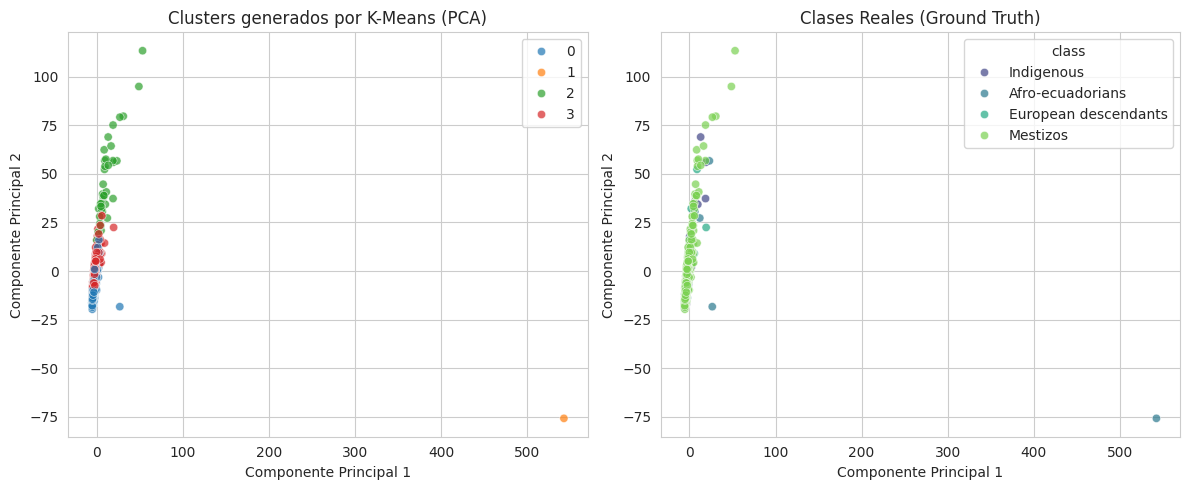

In [9]:

print("Iniciando fase de Clustering con HOG...")

# 1. Cargar el mejor dataset (HOG)
# Asegúrate de que OUTPUT_PATH siga definido en memoria, si no, pon la ruta directa:
# OUTPUT_PATH = '/content/drive/MyDrive/Intregrador/outputs'
ruta_hog = os.path.join(OUTPUT_PATH, 'dataset_hog.csv')

df_hog = pd.read_csv(ruta_hog)
X_hog = df_hog.drop('class', axis=1)
y_real = df_hog['class']

# 2. Estandarización
scaler_clust = StandardScaler()
X_hog_scaled = scaler_clust.fit_transform(X_hog)

# 3. Reducción de Dimensionalidad (PCA) - Conservamos el 90% de la varianza
print("Aplicando PCA para reducir dimensionalidad y costo computacional...")
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_hog_scaled)

print(f"✓ Dimensionalidad reducida de {X_hog.shape[1]} a {X_pca.shape[1]} componentes.")

# 4. Clustering con K-Means (K=4 por las 4 etnias)
print("\nEntrenando K-Means (K=4)...")
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Evaluar la calidad de los clusters
sil_score = silhouette_score(X_pca, clusters)
print(f"✓ K-Means finalizado. Coeficiente de Silhouette: {sil_score:.4f}")

# 5. Visualización de los Clusters usando las 2 primeras componentes principales
plt.figure(figsize=(12, 5))

# Gráfico 1: Los clusters creados por K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', alpha=0.7)
plt.title('Clusters generados por K-Means (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Gráfico 2: Las clases reales para comparar
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_real, palette='viridis', alpha=0.7)
plt.title('Clases Reales (Ground Truth)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

## 8. Tercer Clasificador: K-Nearest Neighbors (KNN)

Para cumplir con la evaluación comparativa de al menos tres algoritmos de clasificación, se implementa K-Nearest Neighbors (KNN). Este modelo basado en instancias clasificará las imágenes buscando los "K" vecinos más cercanos en el espacio de características.

Al igual que en los modelos anteriores, se aplica estandarización (`StandardScaler`) a los datos, un paso obligatorio para que el cálculo de distancias euclidianas de KNN no se vea sesgado por la magnitud de los descriptores (especialmente en HOG y ORB). Se configura con K=5 como valor estándar.

In [13]:


print("Iniciando entrenamiento del tercer clasificador (KNN)...")

archivos_csv = {
    'Momentos de Hu': 'dataset_hu_moments.csv',
    'HOG': 'dataset_hog.csv',
    'ORB': 'dataset_orb.csv'
}

for nombre_desc, archivo in archivos_csv.items():
    print(f"\n{'='*50}")
    print(f" Procesando dataset: {nombre_desc} con KNN")
    print(f"{'='*50}")

    ruta_csv = os.path.join(OUTPUT_PATH, archivo)

    if not os.path.exists(ruta_csv):
        print(f"Error: No se encontró {archivo}")
        continue

    df = pd.read_csv(ruta_csv)
    X = df.drop('class', axis=1)
    y = df['class']

    # Split con estratificación
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Estandarización (Vital para KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- MODELO 3: KNN ---
    inicio_knn = time.time()
    # Usamos n_jobs=-1 para paralelizar el cálculo de distancias
    knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
    knn_model.fit(X_train_scaled, y_train)

    y_pred_knn = knn_model.predict(X_test_scaled)
    tiempo_knn = time.time() - inicio_knn
    acc_knn = accuracy_score(y_test, y_pred_knn)

    print(f"✓ KNN finalizado en {tiempo_knn:.2f} s | Accuracy: {acc_knn:.4f}")
    print(f"\nReporte de Clasificación (KNN) para {nombre_desc}:")
    print(classification_report(y_test, y_pred_knn, zero_division=0))

print("\n¡Fase de modelado supervisado 100% completada!")

Iniciando entrenamiento del tercer clasificador (KNN)...

 Procesando dataset: Momentos de Hu con KNN
✓ KNN finalizado en 0.02 s | Accuracy: 0.5581

Reporte de Clasificación (KNN) para Momentos de Hu:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.00      0.00      0.00        10
European descendants       0.14      0.10      0.12        10
          Indigenous       0.17      0.10      0.12        10
            Mestizos       0.69      0.82      0.75        56

            accuracy                           0.56        86
           macro avg       0.25      0.26      0.25        86
        weighted avg       0.48      0.56      0.52        86


 Procesando dataset: HOG con KNN
✓ KNN finalizado en 0.04 s | Accuracy: 0.6163

Reporte de Clasificación (KNN) para HOG:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.00      0.00      0.00        10
European descendants       0.00      0.00      0.00  

In [16]:
# Consolidación de todas las métricas obtenidas durante el experimento
data = {
    'Descriptor': ['Hu', 'Hu', 'Hu', 'HOG', 'HOG', 'HOG', 'ORB', 'ORB', 'ORB'],
    'Clasificador': ['SVM', 'Random Forest', 'KNN', 'SVM', 'Random Forest', 'KNN', 'SVM', 'Random Forest', 'KNN'],
    'Accuracy Global': [0.2209, 0.6395, 0.5581, 0.6628, 0.6628, 0.6163, 0.5814, 0.6512, 0.5814],
    'Tiempo (s)': [0.02, 0.39, 0.02, 0.94, 1.08, 0.04, 0.08, 0.71, 0.01]
}

df_resultados = pd.DataFrame(data)

# 1. Formatear los números para eliminar los ceros basura
df_resultados['Accuracy Global'] = df_resultados['Accuracy Global'].apply(lambda x: f"{x:.4f}")
df_resultados['Tiempo (s)'] = df_resultados['Tiempo (s)'].apply(lambda x: f"{x:.2f}")

# 2. Agrupar por Descriptor para que la tabla LaTeX use "multirow" (se ve mucho más limpia)
df_agrupado = df_resultados.set_index(['Descriptor', 'Clasificador'])

print("--- TABLA RESUMEN DE RENDIMIENTO ---")
print(df_resultados.to_string(index=False))

--- TABLA RESUMEN DE RENDIMIENTO ---
Descriptor  Clasificador Accuracy Global Tiempo (s)
        Hu           SVM          0.2209       0.02
        Hu Random Forest          0.6395       0.39
        Hu           KNN          0.5581       0.02
       HOG           SVM          0.6628       0.94
       HOG Random Forest          0.6628       1.08
       HOG           KNN          0.6163       0.04
       ORB           SVM          0.5814       0.08
       ORB Random Forest          0.6512       0.71
       ORB           KNN          0.5814       0.01


#Conclusiones Técnicas

1. El Desafío del Desbalanceo de Datos: El factor más crítico que afectó el rendimiento general fue el fuerte sesgo hacia la clase "Mestizos" (razón de 5.6 a 1). A pesar de aplicar técnicas de mitigación como class_weight='balanced' y stratify, los modelos de distancia lineal (como KNN) y los hiperplanos simples (SVM en baja dimensionalidad) colapsaron hacia la clase mayoritaria. Esto subraya que, en tareas de visión artificial de rostros, la calidad y balance del conjunto de datos es tan vital como el modelo matemático elegido.

2. Superioridad de HOG en Rostros: El descriptor HOG (Histogram of Oriented Gradients) demostró ser la técnica de extracción de características más robusta para este dominio. Al capturar distribuciones de gradientes y bordes densos, pudo abstraer mejor la estructura facial independientemente de las condiciones de luz, logrando los Accuracy más altos del experimento (66.28% con Random Forest y SVM).

3. Limitaciones de la Geometría Global: Los Momentos de Hu tuvieron el peor rendimiento general (cayendo hasta un 22% de accuracy con SVM). Esto ocurre porque Hu describe la geometría global de la silueta; al ser todos rostros humanos, la silueta binarizada es prácticamente idéntica entre etnias, haciendo que este descriptor carezca de poder discriminativo para esta tarea específica.

4. Agrupamiento No Supervisado (K-Means): El valor del Coeficiente de Silhouette cercano a cero (0.0247) tras aplicar PCA + K-Means confirma la alta complejidad del problema. Las etnias ecuatorianas comparten una profunda mezcla genética y morfológica, por lo que las características faciales se traslapan enormemente en el espacio vectorial. El algoritmo no supervisado no puede encontrar fronteras de separación naturales claras sin el apoyo de etiquetas